# Neural-Network SARSA and Q-Learning on CartPole-v1

This notebook applies **SARSA** and **Q-learning** to the CartPole control problem using a neural network as the action-value function approximator.

The implementation follows the supplied project:

- CartPole-v1
- 4-dimensional continuous state
- 2 discrete actions
- neural Q-network
- epsilon-greedy exploration
- SARSA and Q-learning TD targets
- online neural-network updates
- 500 training episodes

The final discussion explains why this direct neural-network TD approach can be unstable and how **Deep Q-Networks (DQN)** address the major stability problems.

## 1. CartPole problem

CartPole contains a cart that can move horizontally while balancing a pole.

At every time step, the agent observes the system state and chooses whether to push the cart left or right.

The control objective is:

$$
\boxed{
\text{keep the pole upright for as long as possible}
}
$$

The source project uses:

```python
gym.make("CartPole-v1")
```

and this notebook uses the corresponding current Gymnasium environment.

## 2. State space

The observation contains four continuous values:

$$
\boxed{
S_t=
[x_t,\ \dot{x}_t,\ \theta_t,\ \dot{\theta}_t]
}
$$

where:

- $x_t$ = cart position,
- $\dot{x}_t$ = cart velocity,
- $\theta_t$ = pole angle,
- $\dot{\theta}_t$ = pole angular velocity.

Unlike tabular CliffWalking, CartPole has continuous observations.

Therefore a table such as:

$$
Q[s,a]
$$

cannot be used directly for every possible state.

The implementation replaces the table with a neural network:

$$
\boxed{
Q(s,a;\mathbf w)
}
$$

where $\mathbf w$ denotes all trainable network parameters.

## 3. Action space

There are two discrete actions:

| Action | Meaning |
|---:|---|
| 0 | Push cart left |
| 1 | Push cart right |

The neural network therefore produces two outputs:

$$
\boxed{
Q(s,0;\mathbf w)
}
$$

and:

$$
\boxed{
Q(s,1;\mathbf w).
}
$$

The greedy action is:

$$
\boxed{
A_t=\arg\max_a Q(S_t,a;\mathbf w).
}
$$

## 4. Reward function

The implementation uses the environment reward directly.

CartPole-v1 gives:

$$
\boxed{R_{t+1}=+1}
$$

for each environment step, including the step that ends an episode.

Therefore:

$$
\boxed{
\text{episode return}=\text{episode length}
}
$$

for the standard reward setting.

No custom reward shaping appears in the implementation.

## 5. Episode termination

An episode ends when the physical CartPole failure condition occurs or when the environment reaches its time limit.

The old Gym API used by the supplied scripts returned one flag:

```python
done
```

The current Gymnasium API returns:

```python
terminated
truncated
```

To preserve the source behavior, this notebook defines:

```python
done = terminated or truncated
```

and the  target is replaced by the immediate reward whenever `done` is true.

## 6. Q-network from the implementation

The source uses:

$$
\boxed{
4\rightarrow64\rightarrow32\rightarrow2
}
$$

with ReLU hidden activations:

$$
\text{Dense}(64,\text{ReLU})
$$

$$
\text{Dense}(32,\text{ReLU})
$$

and a linear output layer:

$$
\text{Dense}(2,\text{Linear}).
$$

The output is:

$$
\boxed{
[Q(s,0),Q(s,1)].
}
$$

No replay memory, target network, optimizer object, or mini-batch training is used.

The network is updated immediately after each environment interaction.

## 7. Epsilon-greedy policy

The supplied policy first chooses the greedy action:

$$
A_t^{greedy}
=
\arg\max_a Q(S_t,a).
$$

With probability $\epsilon$, it replaces the greedy action with a uniformly random action.

Therefore:

$$
\boxed{
P(\text{random action})=\epsilon.
}
$$

The source starts with:

$$
\boxed{\epsilon_0=1.0}
$$

and after every episode performs:

$$
\boxed{
\epsilon
\leftarrow
\frac{\epsilon}{1.001}.
}
$$

## 8. The exploration schedule is extremely slow

After $n$ episodes:

$$
\epsilon_n
=
\frac{1}{1.001^n}.
$$

After 500 episodes:

$$
\epsilon_{500}
\approx
\boxed{0.607}.
$$

So even at the end of the supplied training run, the policy still chooses a random action roughly 61% of the time.

This is one reason the raw training reward may remain noisy or fail to show clear improvement.

## 9. SARSA target

SARSA chooses the next action using the same epsilon-greedy behavior policy:

$$
A_{t+1}\sim\pi_\epsilon(\cdot|S_{t+1}).
$$

The target is:

$$
\boxed{
Y_t^{SARSA}
=
R_{t+1}
+
\gamma
Q(S_{t+1},A_{t+1};\mathbf w)
}
$$

for a non-terminal transition.

For a completed episode, the source replaces the target with:

$$
\boxed{
Y_t=R_{t+1}.
}
$$

## 10. Q-learning target

Q-learning chooses the next action using:

```python
next_action = policy(next_state)
```

where the default exploration value is zero.

Therefore:

$$
A^*
=
\arg\max_a Q(S_{t+1},a;\mathbf w).
$$

The target is:

$$
\boxed{
Y_t^{QL}
=
R_{t+1}
+
\gamma
Q(S_{t+1},A^*;\mathbf w)
}
$$

which is equivalent to:

$$
\boxed{
Y_t^{QL}
=
R_{t+1}
+
\gamma
\max_a
Q(S_{t+1},a;\mathbf w).
}
$$

## 11. Manual numerical example

Suppose the network predicts:

$$
Q(S_t,:)
=
[2.0,\ 3.0].
$$

The selected action is:

$$
A_t=1
$$

so:

$$
Q(S_t,A_t)=3.0.
$$

Assume:

$$
R_{t+1}=1
$$

and the relevant next-state estimate is:

$$
Q(S_{t+1},A_{t+1})=4.0.
$$

With:

$$
\gamma=0.99,
$$

the target is:

$$
Y_t
=
1+0.99(4)
=
4.96.
$$

The TD error is:

$$
\delta_t
=
4.96-3.0
=
\boxed{1.96}.
$$

With:

$$
\alpha=0.001,
$$

the intended parameter update is:

$$
\mathbf w
\leftarrow
\mathbf w
+
0.001(1.96)
\nabla_{\mathbf w}
Q(S_t,1;\mathbf w).
$$

Therefore:

$$
\boxed{
\mathbf w
\leftarrow
\mathbf w
+
0.00196
\nabla_{\mathbf w}
Q(S_t,1;\mathbf w)
}
$$

## 12. Colab setup

In [1]:
%pip -q install "gymnasium[classic-control]" imageio imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 41.5 MB/s eta 0:00:00


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from IPython.display import display, Video
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
print("TensorFlow:", tf.__version__)
print("Gymnasium:", gym.__version__)

TensorFlow: 2.21.0
Gymnasium: 1.3.0


## 13. Environment inspection

In [3]:
env = gym.make("CartPole-v1")
state, info = env.reset(seed=SEED)
print("Initial state:", state)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Maximum episode steps:", env.spec.max_episode_steps)
env.close()

Initial state: [ 0.0274 -0.0061  0.0359  0.0197]
Observation space: Box([-4.8       -inf -0.4189    -inf], [4.8       inf 0.4189    inf], (4,), float32)
Action space: Discrete(2)
Maximum episode steps: 500


## 14. Hyperparameters

In [4]:
ALPHA = 0.001
INITIAL_EPSILON = 1.0
EPSILON_DECAY = 1.001
GAMMA = 0.99
NUM_EPISODES = 500
NUM_ACTIONS = 2
ACTION_NAMES = ["Left", "Right"]
print("Alpha:", ALPHA)
print("Initial epsilon:", INITIAL_EPSILON)
print("Epsilon decay:", EPSILON_DECAY)
print("Gamma:", GAMMA)
print("Episodes:", NUM_EPISODES)

Alpha: 0.001
Initial epsilon: 1.0
Epsilon decay: 1.001
Gamma: 0.99
Episodes: 500


## 15. Q-network

In [5]:
def build_q_network(seed=SEED):
    tf.keras.utils.set_random_seed(seed)
    net_input = Input(shape=(4,))
    x = Dense(64, activation="relu")(net_input)
    x = Dense(32, activation="relu")(x)
    output = Dense(2, activation="linear")(x)
    q_network = Model(inputs=net_input, outputs=output)
    return q_network

demo_network = build_q_network()
demo_network.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,466 (9.63 KB)

 Trainable params: 2,466 (9.63 KB)

 Non-trainable params: 0 (0.00 B)

## 16. epsilon-greedy policy

In [6]:
def policy(q_network, state_tensor, explore=0.0):
    action = tf.argmax(q_network(state_tensor)[0], output_type=tf.int32)
    if tf.random.uniform(shape=(), maxval=1) <= explore:
        action = tf.random.uniform(shape=(), minval=0, maxval=2, dtype=tf.int32)
    return action

## 17. Visualize the epsilon schedule

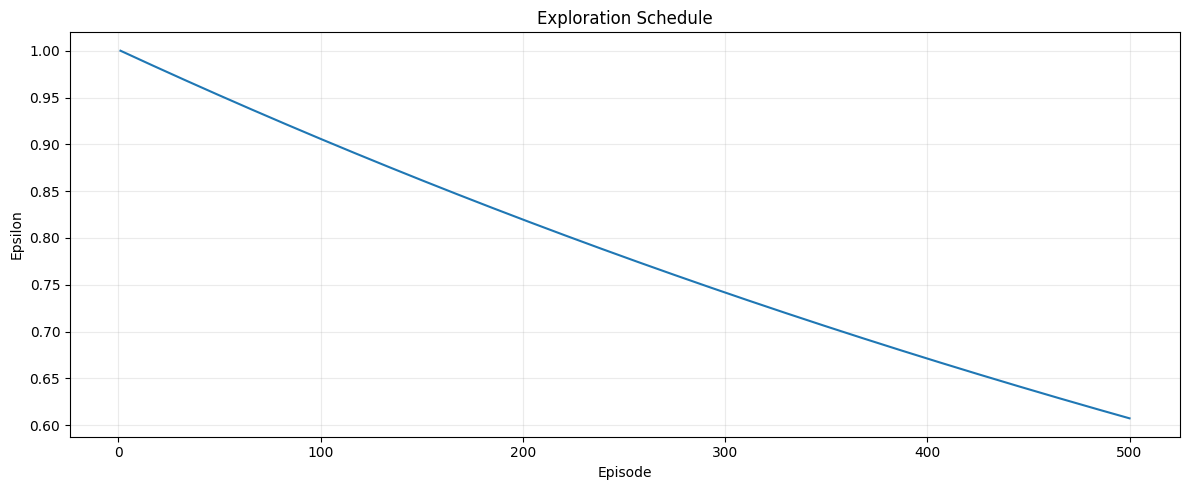

Initial epsilon: 1.0
Epsilon at episode 500: 0.6072888925056174


In [7]:
epsilon_values = []
epsilon = INITIAL_EPSILON
for episode in range(NUM_EPISODES):
    epsilon_values.append(epsilon)
    epsilon = epsilon / EPSILON_DECAY
plt.figure(figsize=(12, 5))
plt.plot(np.arange(1, NUM_EPISODES + 1), epsilon_values)
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Exploration Schedule")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
print("Initial epsilon:", epsilon_values[0])
print("Epsilon at episode 500:", epsilon_values[-1])

## 18. Random-agent baseline

In [8]:
def run_random_agent(episodes=100, seed=SEED):
    env = gym.make("CartPole-v1")
    rewards = []
    lengths = []
    for episode in range(episodes):
        state, info = env.reset(seed=seed + episode)
        env.action_space.seed(seed + episode)
        total_reward = 0.0
        episode_length = 0
        done = False
        while not done:
            action = env.action_space.sample()
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += float(reward)
            episode_length += 1
        rewards.append(total_reward)
        lengths.append(episode_length)
    env.close()
    return pd.DataFrame({"episode": np.arange(1, episodes + 1), "reward": rewards, "length": lengths})

random_history = run_random_agent()
display(random_history.head())
print("Random mean reward:", random_history["reward"].mean())
print("Random mean episode length:", random_history["length"].mean())

,episode,reward,length
0,1,30.0,30
1,2,93.0,93
2,3,44.0,44
3,4,10.0,10
4,5,20.0,20


Random mean reward: 25.49
Random mean episode length: 25.49


## 19. Neural-network update

The implementation performs an online neural-network update after every environment transition.

The project code first evaluates the complete Q-network output:

```python
with tf.GradientTape() as tape:
    current = q_net(state)
```

so:

$$
current=
[Q(S_t,0),Q(S_t,1)].
$$

It then calculates the TD error using the action that was actually selected:

$$
\boxed{
\delta_t
=
Y_t-Q(S_t,A_t).
}
$$

Finally, the weights are changed using:

```python
grads = tape.gradient(current, q_net.trainable_weights)

for j in range(len(grads)):
    q_net.trainable_weights[j].assign_add(
        ALPHA * delta * grads[j]
    )
```

This is the update used by the project and is implemented unchanged below.

An important consequence is discussed later in the notebook: the gradient is calculated from the complete two-action output vector rather than only the selected action value $Q(S_t,A_t)$. That can make the neural-network update unstable.

In [9]:
def update_network(q_network, state_tensor, action, target, alpha):
    with tf.GradientTape() as tape:
        current = q_network(state_tensor)
    gradients = tape.gradient(current, q_network.trainable_weights)
    delta = target - current[0][action]
    for index in range(len(gradients)):
        q_network.trainable_weights[index].assign_add(alpha * delta * gradients[index])
    return float(delta.numpy())

## 20. SARSA training

In [10]:
def train_sarsa(num_episodes=NUM_EPISODES, seed=SEED):
    tf.keras.utils.set_random_seed(seed)
    env = gym.make("CartPole-v1")
    q_network = build_q_network(seed)
    epsilon = INITIAL_EPSILON
    rewards = []
    lengths = []
    epsilons = []
    mean_abs_td_errors = []
    for episode in range(num_episodes):
        state, info = env.reset(seed=seed + episode)
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        action = policy(q_network, state_tensor, epsilon)
        total_reward = 0.0
        episode_length = 0
        td_errors = []
        done = False
        while not done:
            next_state, reward, terminated, truncated, info = env.step(int(action.numpy()))
            done = terminated or truncated
            next_state_tensor = tf.convert_to_tensor([next_state], dtype=tf.float32)
            next_action = policy(q_network, next_state_tensor, epsilon)
            target = reward + GAMMA * q_network(next_state_tensor)[0][next_action]
            if done:
                target = tf.convert_to_tensor(reward, dtype=tf.float32)
            delta = update_network(q_network, state_tensor, action, target, ALPHA)
            td_errors.append(abs(delta))
            state_tensor = next_state_tensor
            action = next_action
            total_reward += float(reward)
            episode_length += 1
        rewards.append(total_reward)
        lengths.append(episode_length)
        epsilons.append(epsilon)
        mean_abs_td_errors.append(np.mean(td_errors))
        epsilon = epsilon / EPSILON_DECAY
    env.close()
    history = pd.DataFrame({"episode": np.arange(1, num_episodes + 1), "reward": rewards, "length": lengths, "epsilon": epsilons, "mean_abs_td_error": mean_abs_td_errors})
    return q_network, history

## 21. Q-learning training

In [11]:
def train_q_learning(num_episodes=NUM_EPISODES, seed=SEED + 1):
    tf.keras.utils.set_random_seed(seed)
    env = gym.make("CartPole-v1")
    q_network = build_q_network(seed)
    epsilon = INITIAL_EPSILON
    rewards = []
    lengths = []
    epsilons = []
    mean_abs_td_errors = []
    for episode in range(num_episodes):
        state, info = env.reset(seed=seed + episode)
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        total_reward = 0.0
        episode_length = 0
        td_errors = []
        done = False
        while not done:
            action = policy(q_network, state_tensor, epsilon)
            next_state, reward, terminated, truncated, info = env.step(int(action.numpy()))
            done = terminated or truncated
            next_state_tensor = tf.convert_to_tensor([next_state], dtype=tf.float32)
            next_action = policy(q_network, next_state_tensor, 0.0)
            target = reward + GAMMA * q_network(next_state_tensor)[0][next_action]
            if done:
                target = tf.convert_to_tensor(reward, dtype=tf.float32)
            delta = update_network(q_network, state_tensor, action, target, ALPHA)
            td_errors.append(abs(delta))
            state_tensor = next_state_tensor
            total_reward += float(reward)
            episode_length += 1
        rewards.append(total_reward)
        lengths.append(episode_length)
        epsilons.append(epsilon)
        mean_abs_td_errors.append(np.mean(td_errors))
        epsilon = epsilon / EPSILON_DECAY
    env.close()
    history = pd.DataFrame({"episode": np.arange(1, num_episodes + 1), "reward": rewards, "length": lengths, "epsilon": epsilons, "mean_abs_td_error": mean_abs_td_errors})
    return q_network, history

## 22. Train both algorithms

In [12]:
sarsa_network, sarsa_history = train_sarsa()
q_learning_network, q_learning_history = train_q_learning()
print("SARSA training complete.")
print("Q-learning training complete.")

SARSA training complete.
Q-learning training complete.


## 23. Actual reward vs. episode

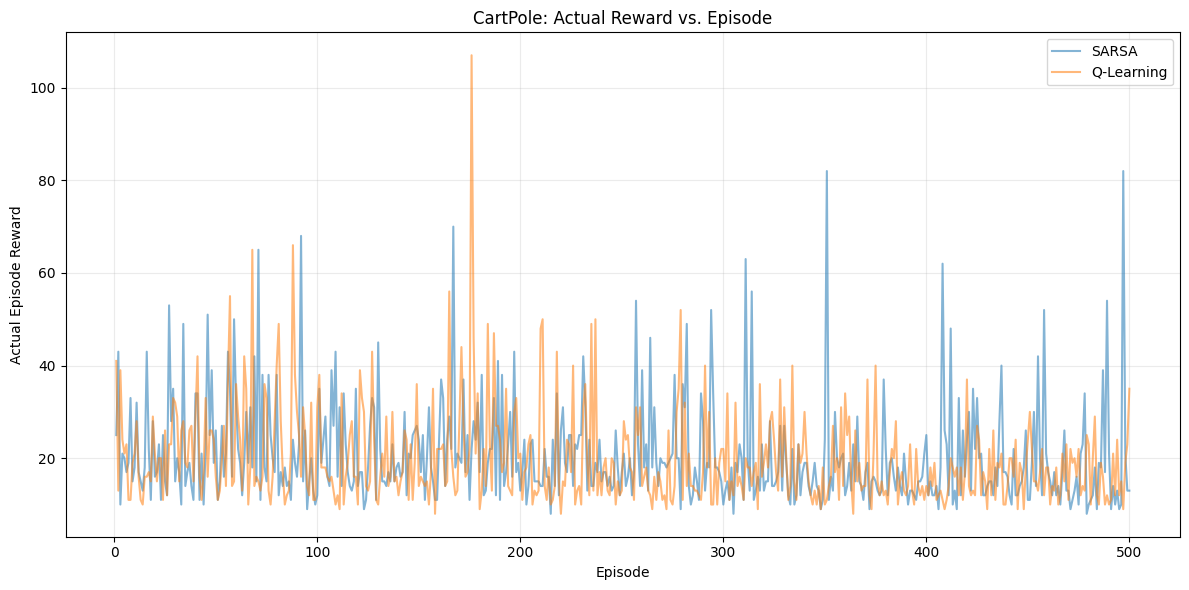

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(sarsa_history["episode"], sarsa_history["reward"], alpha=0.55, label="SARSA")
plt.plot(q_learning_history["episode"], q_learning_history["reward"], alpha=0.55, label="Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Actual Episode Reward")
plt.title("CartPole: Actual Reward vs. Episode")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 24. Reward moving average

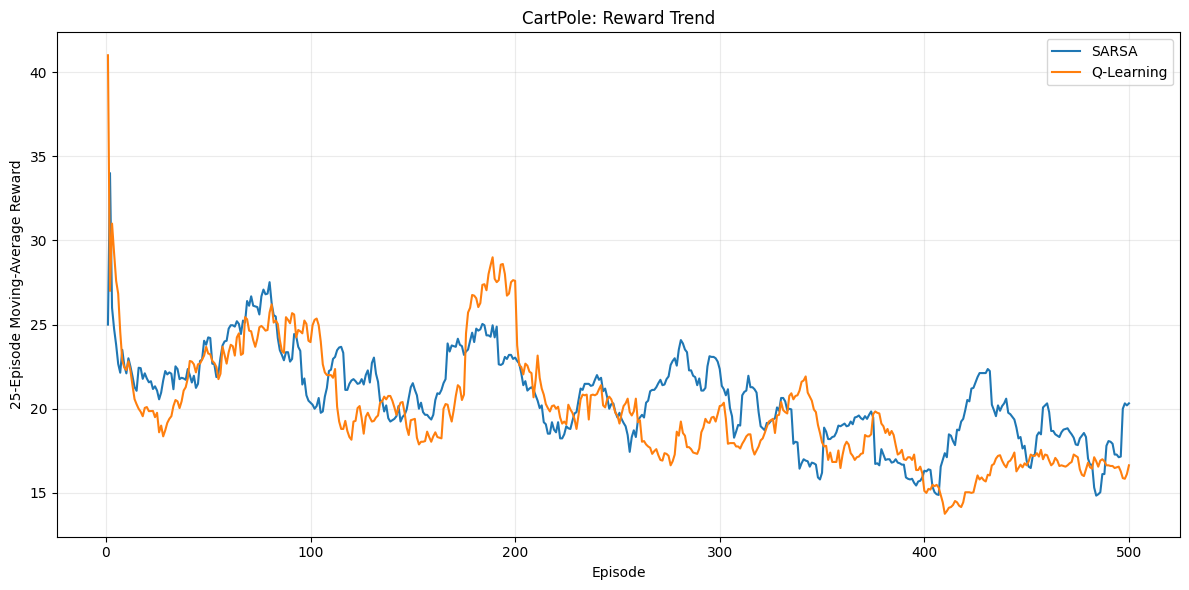

In [14]:
WINDOW = 25
source_sarsa_reward_ma = sarsa_history["reward"].rolling(WINDOW, min_periods=1).mean()
source_q_reward_ma = q_learning_history["reward"].rolling(WINDOW, min_periods=1).mean()
plt.figure(figsize=(12, 6))
plt.plot(sarsa_history["episode"], source_sarsa_reward_ma, label="SARSA")
plt.plot(q_learning_history["episode"], source_q_reward_ma, label="Q-Learning")
plt.xlabel("Episode")
plt.ylabel(f"{WINDOW}-Episode Moving-Average Reward")
plt.title("CartPole: Reward Trend")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 25. TD-error diagnostic

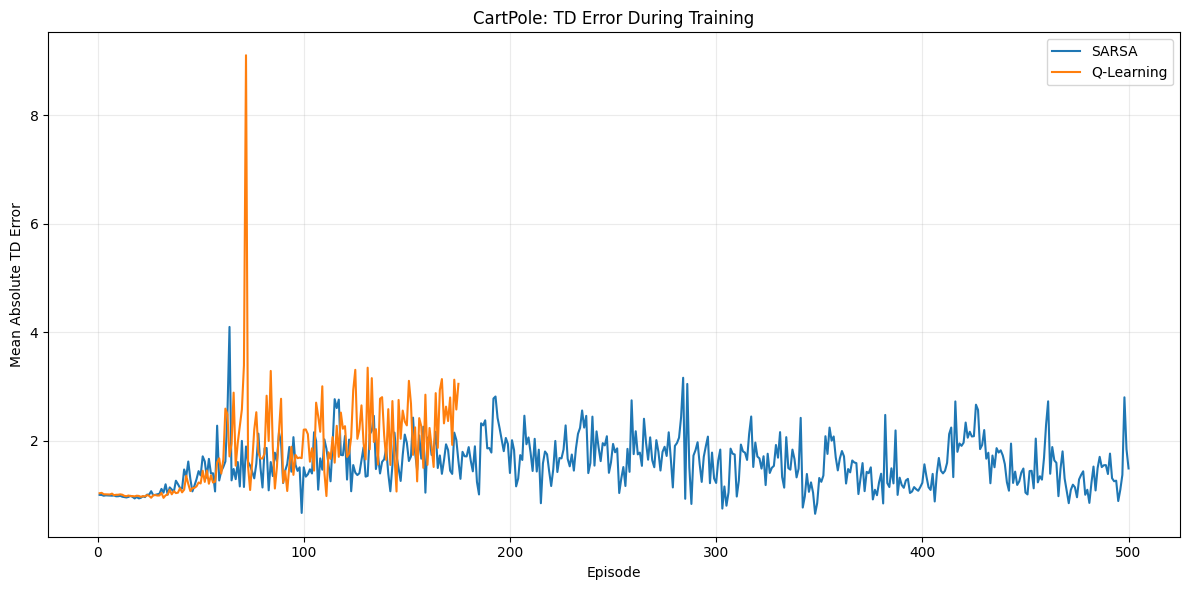

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(sarsa_history["episode"], sarsa_history["mean_abs_td_error"], label="SARSA")
plt.plot(q_learning_history["episode"], q_learning_history["mean_abs_td_error"], label="Q-Learning")
plt.xlabel("Episode")
plt.ylabel("Mean Absolute TD Error")
plt.title("CartPole: TD Error During Training")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 26. Greedy evaluation function

In [16]:
def evaluate_network(q_network, episodes=20, seed=10000):
    env = gym.make("CartPole-v1")
    records = []
    for episode in range(episodes):
        state, info = env.reset(seed=seed + episode)
        total_reward = 0.0
        episode_length = 0
        done = False
        while not done:
            state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
            action = int(tf.argmax(q_network(state_tensor)[0]).numpy())
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += float(reward)
            episode_length += 1
        records.append({"episode": episode + 1, "reward": total_reward, "length": episode_length})
    env.close()
    return pd.DataFrame(records)

## 27. Evaluate all learned policies

In [17]:
sarsa_eval = evaluate_network(sarsa_network)
q_learning_eval = evaluate_network(q_learning_network)

print("SARSA")
display(sarsa_eval)

print("Q-learning")
display(q_learning_eval)

SARSA


,episode,reward,length
0,1,15.0,15
1,2,13.0,13
2,3,14.0,14
3,4,19.0,19
4,5,14.0,14
5,6,15.0,15
6,7,9.0,9
7,8,14.0,14
8,9,11.0,11
9,10,10.0,10


Q-learning


,episode,reward,length
0,1,9.0,9
1,2,10.0,10
2,3,9.0,9
3,4,8.0,8
4,5,10.0,10
5,6,8.0,8
6,7,10.0,10
7,8,10.0,10
8,9,9.0,9
9,10,9.0,9


## 28. Evaluation summary

In [18]:
summary_df = pd.DataFrame({
    "Policy": ["Random", "SARSA", "Q-Learning"],
    "Mean Reward": [
        random_history["reward"].mean(),
        sarsa_eval["reward"].mean(),
        q_learning_eval["reward"].mean()
    ],
    "Mean Episode Length": [
        random_history["length"].mean(),
        sarsa_eval["length"].mean(),
        q_learning_eval["length"].mean()
    ]
})

display(summary_df)

,Policy,Mean Reward,Mean Episode Length
0,Random,25.49,25.49
1,SARSA,12.25,12.25
2,Q-Learning,9.40,9.40


## 29. Evaluation reward comparison

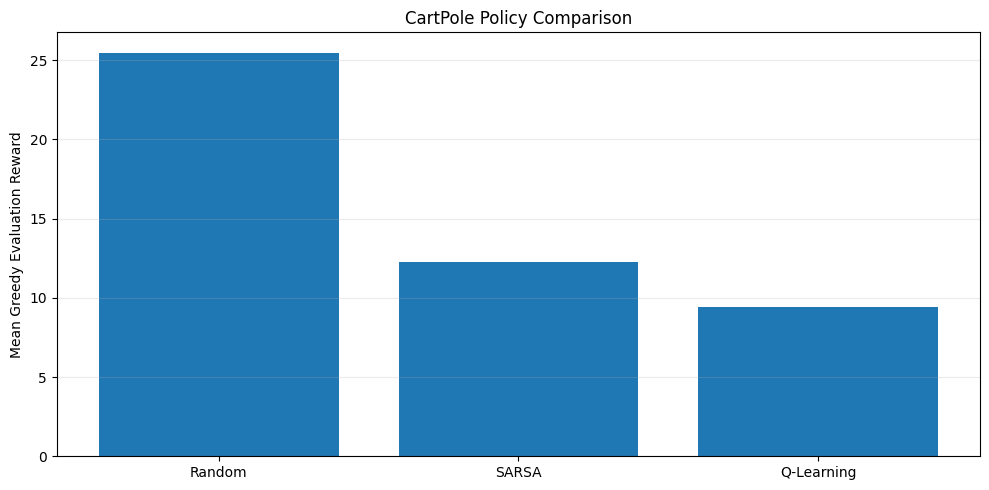

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(summary_df["Policy"], summary_df["Mean Reward"])
plt.ylabel("Mean Greedy Evaluation Reward")
plt.title("CartPole Policy Comparison")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation of the current run

The saved execution of this notebook gives approximately:

| Policy | Mean evaluation reward |
|---|---:|
| Random | 25.49 |
| SARSA | 12.25 |
| Q-learning | 9.40 |

Because CartPole gives approximately one reward point for every balanced time step, these values also represent the average episode lengths.

In this run:

$$
\boxed{
\text{Random}>\text{SARSA}>\text{Q-learning}.
}
$$

Therefore neither neural-network TD method learned a reliable CartPole controller.

This is not a reason to alter the implementation in this notebook. It is the experimental result produced by the approach and motivates the later DQN implementation.

The Q-learning evaluation video lasting only around 10 steps and the `NaN` Q-values provide additional evidence that the Q-learning network became unstable rather than converging to a useful action-value function.

## 30. Why training reward and evaluation reward can differ

The training policy remains highly exploratory.

The implementation starts with:

$$
\epsilon_0=1.0
$$

and after every episode uses:

$$
\epsilon
\leftarrow
\frac{\epsilon}{1.001}.
$$

After 500 episodes:

$$
\epsilon_{500}\approx0.607.
$$

Therefore many training actions are still random near the end of training.

Evaluation uses:

$$
\epsilon=0,
$$

so it follows the greedy policy.

For that reason, the greedy evaluation reward can be noticeably better than the noisy training reward.

## 31. Inspect Q-values for representative states

In [20]:
representative_states = np.asarray([
    [0.0, 0.0, 0.0, 0.0],
    [0.0, 0.5, 0.05, 0.0],
    [0.0, -0.5, -0.05, 0.0],
    [0.5, 0.0, 0.10, 0.5],
    [-0.5, 0.0, -0.10, -0.5]
], dtype=np.float32)

rows = []

for index, state in enumerate(representative_states):
    state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
    sarsa_values = sarsa_network(state_tensor).numpy()[0]
    q_learning_values = q_learning_network(state_tensor).numpy()[0]
    rows.append({
        "State": index,
        "SARSA Q(Left)": sarsa_values[0],
        "SARSA Q(Right)": sarsa_values[1],
        "Q-Learning Q(Left)": q_learning_values[0],
        "Q-Learning Q(Right)": q_learning_values[1]
    })

display(pd.DataFrame(rows))

,State,SARSA Q(Left),SARSA Q(Right),Q-Learning Q(Left),Q-Learning Q(Right)
0,0,15.2391,15.5372,NaN,NaN
1,1,18.0784,18.3830,NaN,NaN
2,2,11.7950,12.0586,NaN,NaN
3,3,15.6324,15.9614,NaN,NaN
4,4,13.5543,13.9083,NaN,NaN


### Numerical-stability diagnostic

The following diagnostic checks whether the two trained networks return finite Q-values.

A finite result means:

$$
Q(s,a)\in\mathbb R.
$$

If the result is `False`, at least one prediction contains `NaN` or infinity, which indicates numerical divergence of the learned value function rather than a display or missing-data problem.

In [21]:
sarsa_test_values = sarsa_network(representative_states).numpy()
q_learning_test_values = q_learning_network(representative_states).numpy()

sarsa_is_finite = np.isfinite(sarsa_test_values).all()
q_learning_is_finite = np.isfinite(q_learning_test_values).all()

print("SARSA Q-values finite:", sarsa_is_finite)
print("Q-learning Q-values finite:", q_learning_is_finite)

if not sarsa_is_finite:
    print("SARSA warning: the Q-network has numerically diverged.")

if not q_learning_is_finite:
    print("Q-learning warning: the Q-network has numerically diverged and contains NaN or infinite values.")

SARSA Q-values finite: True
Q-learning Q-values finite: False
Q-learning warning: the Q-network has numerically diverged and contains NaN or infinite values.


## 32. Policy map over pole angle and angular velocity

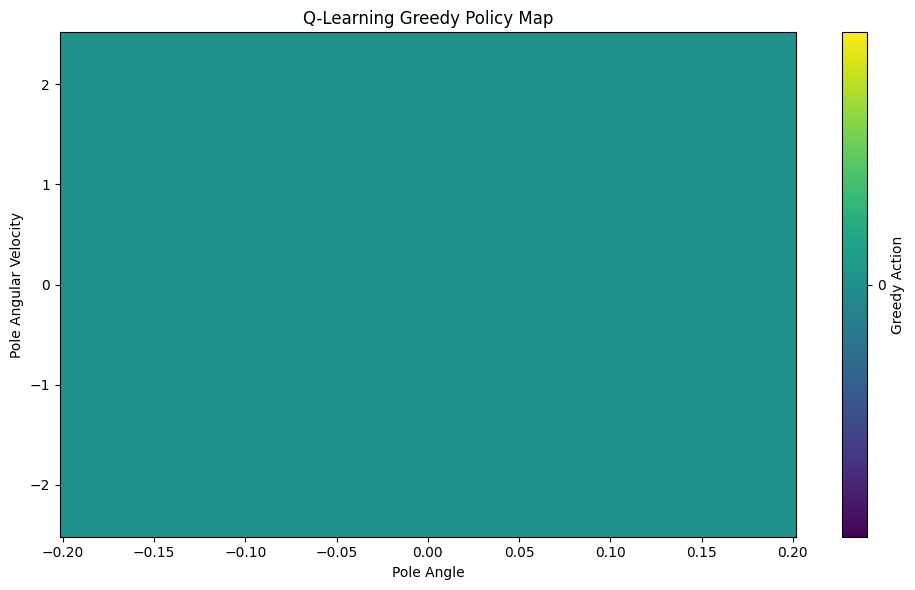

In [22]:
def plot_policy_map(q_network, title):
    angles = np.linspace(-0.20, 0.20, 121)
    angular_velocities = np.linspace(-2.5, 2.5, 121)
    angle_grid, angular_velocity_grid = np.meshgrid(angles, angular_velocities)
    states = np.column_stack([
        np.zeros(angle_grid.size),
        np.zeros(angle_grid.size),
        angle_grid.ravel(),
        angular_velocity_grid.ravel()
    ]).astype(np.float32)
    q_values = q_network(states).numpy()
    actions = np.argmax(q_values, axis=1).reshape(angle_grid.shape)
    plt.figure(figsize=(10, 6))
    mesh = plt.pcolormesh(angle_grid, angular_velocity_grid, actions, shading="auto")
    plt.colorbar(mesh, ticks=[0, 1], label="Greedy Action")
    plt.xlabel("Pole Angle")
    plt.ylabel("Pole Angular Velocity")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_policy_map(q_learning_network, "Q-Learning Greedy Policy Map")

## 33. Save trained models

In [23]:
sarsa_network.save("sarsa_q_net.keras")
q_learning_network.save("q_learning_q_net.keras")
print("Saved SARSA and Q-learning networks.")

Saved SARSA and Q-learning networks.


## 34. Record a greedy evaluation video

In [24]:
def record_cartpole_video(q_network, filename, label, seed=30000, fps=30):
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    state, info = env.reset(seed=seed)
    frames = [env.render()]
    total_reward = 0.0
    episode_length = 0
    done = False
    while not done:
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        action = int(tf.argmax(q_network(state_tensor)[0]).numpy())
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += float(reward)
        episode_length += 1
        frames.append(env.render())
    env.close()
    imageio.mimsave(filename, frames, fps=fps)
    print("Policy:", label)
    print("Video:", filename)
    print("Reward:", total_reward)
    print("Episode length:", episode_length)
    return filename

In [25]:
video_file = record_cartpole_video(q_learning_network, "cartpole_q_learning.mp4", "Q-Learning")
display(Video(video_file, embed=True))

Policy: Q-Learning
Video: cartpole_q_learning.mp4
Reward: 10.0
Episode length: 10


## 35. SARSA pseudocode

```text
Initialize neural network Q(s,a;w)

epsilon = 1.0

For 500 episodes:

    Reset CartPole

    Choose A from S using epsilon-greedy

    Repeat until done:

        Execute A

        Observe:
            R
            S'

        Choose A' from S'
        using epsilon-greedy

        if not done:

            target =
                R
                + gamma * Q(S', A')

        else:

            target = R

        delta =
            target
            - Q(S,A)

        Network gradient:
            gradient of complete Q(S,:) output used by this implementation

        w =
            w
            + alpha
              * delta
              * gradient

        S = S'
        A = A'

    epsilon =
        epsilon / 1.001
```

## 36. Q-learning pseudocode

```text
Initialize neural network Q(s,a;w)

epsilon = 1.0

For 500 episodes:

    Reset CartPole

    Repeat until done:

        Choose A from S
        using epsilon-greedy

        Execute A

        Observe:
            R
            S'

        A* =
            argmax_a Q(S',a)

        if not done:

            target =
                R
                + gamma * Q(S', A*)

        else:

            target = R

        delta =
            target
            - Q(S,A)

        Network gradient:
            gradient of complete Q(S,:) output used by this implementation

        w =
            w
            + alpha
              * delta
              * gradient

        S = S'

    epsilon =
        epsilon / 1.001
```

## 37. Why can neural-network SARSA and Q-learning be unstable?

The experiment demonstrates an important reinforcement-learning lesson:

$$
\boxed{
\text{Replacing a Q-table with a neural network does not automatically create stable deep RL.}
}
$$

The project notes that directly applying neural networks to SARSA and Q-learning did not work particularly well. The training and evaluation results in this notebook illustrate why.

### 37.1 The update uses the gradient of the complete output vector

For one state, the network produces:

$$
Q(S_t,:)
=
[Q(S_t,0),Q(S_t,1)].
$$

The code computes:

```python
with tf.GradientTape() as tape:
    current = q_net(state)

grads = tape.gradient(current, q_net.trainable_weights)
```

while the TD error is:

$$
\delta_t
=
Y_t-Q(S_t,A_t).
$$

Because `current` contains both output values, TensorFlow differentiates the complete output tensor with respect to the weights. In effect, the selected-action TD error is multiplied by a gradient influenced by **both action outputs**.

A conventional semi-gradient action-value update would instead use:

$$
\boxed{
\nabla_{\mathbf w}
Q(S_t,A_t;\mathbf w)
}
$$

for the action that was actually selected.

This implementation detail can cause parameters associated with the other action value to change even though the TD error was calculated for only one action. Repeated updates can therefore push the value estimates in unstable directions.

### 37.2 `NaN` Q-values indicate numerical divergence

In the executed results above, the Q-learning network produces:

```text
Q-Learning Q(Left)  = NaN
Q-Learning Q(Right) = NaN
```

for the representative states.

`NaN` means **Not a Number**. It is not a missing-data symbol here.

It means numerical values inside the network became invalid during training, typically after values or gradients became excessively large or otherwise numerically unstable.

Once Q-values become `NaN`, the learned value function has diverged:

$$
\boxed{
Q(s,a;\mathbf w)\rightarrow\text{NaN}.
}
$$

At that point, the resulting greedy policy is no longer based on meaningful action-value estimates.

### 37.3 The current evaluation confirms that useful control was not learned

For the saved execution of this notebook:

$$
\text{Random mean reward}\approx25.49,
$$

while:

$$
\text{SARSA greedy mean reward}\approx12.25,
$$

and:

$$
\text{Q-learning greedy mean reward}\approx9.40.
$$

The Q-learning evaluation video also lasts only about 10 steps.

Therefore, in this particular run:

$$
\boxed{
\text{the learned policies do not outperform the random baseline.}
}
$$

That result is consistent with an unstable value-function learning process rather than successful CartPole control.

### 37.4 Consecutive training samples are strongly correlated

The network learns immediately from:

$$
(S_t,A_t,R_{t+1},S_{t+1})
$$

and then from the very next transition:

$$
(S_{t+1},A_{t+1},R_{t+2},S_{t+2}).
$$

Those observations are highly correlated.

Neural networks are generally easier to optimize when training samples are more diverse rather than coming from one strongly correlated trajectory in strict order.

### 37.5 The same network produces both the estimate and bootstrap target

For Q-learning:

$$
Y_t
=
R_{t+1}
+
\gamma
\max_a
Q(S_{t+1},a;\mathbf w).
$$

The same parameters $\mathbf w$ are used to:

1. estimate the current value $Q(S_t,A_t;\mathbf w)$, and
2. construct the target from $Q(S_{t+1},a;\mathbf w)$.

But those parameters are being changed after every transition.

Therefore the network is trying to chase a target that is itself moving:

$$
\boxed{
\text{updated network}
\rightarrow
\text{changed target}
\rightarrow
\text{another update}
\rightarrow
\text{another changed target}.
}
$$

This can create oscillation or divergence.

### 37.6 Bootstrapping magnifies estimation errors

SARSA and Q-learning are TD methods, so their targets contain another estimated Q-value.

For example:

$$
Y_t
=
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1}).
$$

If the next-state estimate is inaccurate, that error enters the new target.

The newly updated estimate is then used to create later targets.

With nonlinear function approximation, errors can therefore propagate through many updates.

### 37.7 Q-learning also uses a maximum over estimated values

Q-learning uses:

$$
\max_a Q(S_{t+1},a).
$$

If one noisy estimate is accidentally too large, the maximum operator tends to select it.

That overly optimistic value can enter the bootstrap target and influence subsequent updates.

This is another reason unstable estimates can grow instead of automatically correcting themselves.

### 37.8 Exploration remains very high

The project uses:

$$
\epsilon_0=1.0
$$

and:

$$
\epsilon
\leftarrow
\frac{\epsilon}{1.001}
$$

after every episode.

After 500 episodes:

$$
\epsilon_{500}
\approx0.607.
$$

So roughly 61% exploration still remains near the end of training.

This does not by itself cause numerical divergence, but it makes training rewards highly variable and prevents the behavior policy from becoming strongly greedy during the 500-episode experiment.

### 37.9 No replay memory or separate target network

The implementation updates directly from the latest transition.

It does not contain:

- an experience replay buffer,
- random mini-batches,
- a separate target Q-network.

Those mechanisms are introduced in DQN specifically to make neural-network Q-learning more stable.

### What this result means

The poor performance should not be interpreted as evidence that SARSA or Q-learning are fundamentally unusable.

The important issue is the combination of:

$$
\boxed{
\text{TD bootstrapping}
+
\text{nonlinear function approximation}
+
\text{online correlated updates}
+
\text{moving targets}.
}
$$

This experiment therefore provides a natural motivation for DQN.

## 38. How DQN improves stability

Deep Q-Networks still approximate the action-value function with a neural network:

$$
\boxed{
Q(s,a;\mathbf w).
}
$$

The difference is that DQN adds mechanisms specifically designed to address the instability observed in the previous experiment.

### 38.1 Experience replay breaks the strong temporal correlation

Instead of updating only from the newest transition, DQN stores experiences:

$$
\boxed{
(S_t,A_t,R_{t+1},S_{t+1},d_t)
}
$$

in a replay buffer.

Training then uses randomly sampled mini-batches:

$$
\boxed{
\mathcal B
=
\{(S_i,A_i,R_i,S_i',d_i)\}_{i=1}^{N}.
}
$$

Because samples come from different moments in previous episodes, the training batch is less temporally correlated.

This directly addresses the problem:

$$
\text{consecutive correlated transitions}
\quad\longrightarrow\quad
\text{random replay samples}.
$$

### 38.2 A target network reduces the moving-target problem

DQN maintains two networks.

The **online network** is:

$$
Q(s,a;\mathbf w).
$$

The **target network** is:

$$
Q(s,a;\mathbf w^-).
$$

The target is calculated using the more slowly changing target network:

$$
\boxed{
Y_i
=
R_i
+
\gamma(1-d_i)
\max_a
Q(S_i',a;\mathbf w^-).
}
$$

The online network is trained toward this target, while $\mathbf w^-$ remains fixed for a period of time.

Therefore:

$$
\boxed{
\text{the learning target changes more slowly}.
}
$$

This is much more stable than using the same rapidly changing network for both sides of the TD update.

### 38.3 DQN trains the Q-value for the selected action

For a batch of network outputs:

$$
Q(S_i,:),
$$

DQN selects:

$$
\boxed{
Q(S_i,A_i)
}
$$

for each transition.

The loss is then calculated using the selected action values:

$$
\boxed{
L(\mathbf w)
=
\frac1N
\sum_{i=1}^{N}
\ell
\left(
Y_i,
Q(S_i,A_i;\mathbf w)
\right).
}
$$

This makes the relationship between the sampled action, its TD target, and its gradient explicit.

### 38.4 Mini-batch optimization provides a more stable gradient

Instead of changing the network from one transition at a time, DQN averages information over many replay samples.

For mean-squared error, the idea is:

$$
L(\mathbf w)
=
\frac1N
\sum_{i=1}^{N}
\left[
Y_i-Q(S_i,A_i;\mathbf w)
\right]^2.
$$

The DQN project that follows this notebook uses mini-batch training and a robust Huber loss.

### 38.5 The transition from this notebook to DQN

The progression is therefore:

$$
\boxed{
\text{Tabular SARSA/Q-learning}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Neural-network SARSA/Q-learning}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{Instability observed}
}
$$

$$
\downarrow
$$

$$
\boxed{
\text{DQN}
}
$$

with:

$$
\boxed{
\text{Replay Buffer}
+
\text{Target Network}
+
\text{Mini-batch Training}.
}
$$

This is the central lesson of the experiment: a neural network provides function approximation, but **DQN adds the training machinery needed to make neural value learning substantially more stable**.

## References

1. Sutton, R. S., & Barto, A. G. *Reinforcement Learning: An Introduction*, 2nd ed.
2. Gymnasium documentation: CartPole-v1.
3. Supplied project files: `sarsa_cartpole.py`, `q_learning_cartpole.py`, `random_agent.py`, `evaluator.py`, `README.md`, and `requirements.txt`.